# MLP and CNN experiment report

This notebook loads the saved JSON files from `results/` and keeps the MLP and CNN experiments separate. Plot titles and summary tables include the architecture, dataset, and run id so it is clear which experiment produced each curve.


In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


RESULTS_DIR = Path("results")
result_paths = sorted(RESULTS_DIR.glob("*.json"))

result_paths


[WindowsPath('results/cnn_cifar100_20260501_110013.json'),
 WindowsPath('results/cnn_cifar10_20260501_102657.json'),
 WindowsPath('results/cnn_fashionmnist_20260501_094847.json'),
 WindowsPath('results/cnn_mnist_20260501_092632.json'),
 WindowsPath('results/mlp_cifar100_20260501_120416.json'),
 WindowsPath('results/mlp_cifar10_20260501_114321.json'),
 WindowsPath('results/mlp_fashionmnist_20260501_111943.json'),
 WindowsPath('results/mlp_mnist_20260501_110944.json')]

## Load and organize results


In [2]:
METHOD_LABELS = {
    "mono_ff": "MonoFWD FF",
    "mono_bp": "MonoFWD BP",
    "bp": "Backprop",
}

MODEL_LABELS = {
    "mlp": "MLP",
    "cnn": "CNN",
}

DATASET_LABELS = {
    "mnist": "MNIST",
    "fashionmnist": "Fashion-MNIST",
    "cifar10": "CIFAR-10",
    "cifar100": "CIFAR-100",
}


def parse_result_filename(path: Path) -> tuple[str, str, str]:
    model, dataset, *run_parts = path.stem.split("_")
    return model, dataset, "_".join(run_parts)


def load_experiment_history(path: Path) -> pd.DataFrame:
    with path.open() as f:
        raw = json.load(f)

    model, dataset, run_id = parse_result_filename(path)
    model_label = MODEL_LABELS.get(model, model.upper())
    dataset_label = DATASET_LABELS.get(dataset, dataset.upper())

    rows = []
    for method, metrics in raw.items():
        if method not in METHOD_LABELS:
            continue

        max_train_epoch = len(metrics.get("train_losses", []))
        for metric, values in metrics.items():
            if not isinstance(values, list):
                continue

            is_final_test_metric = metric.startswith("test_") and len(values) == 1
            for index, value in enumerate(values, start=1):
                epoch = max_train_epoch if is_final_test_metric else index
                rows.append(
                    {
                        "file": path.name,
                        "model": model,
                        "model_label": model_label,
                        "dataset": dataset,
                        "dataset_label": dataset_label,
                        "run_id": run_id,
                        "experiment": f"{model_label} / {dataset_label} / {run_id}",
                        "method": method,
                        "method_label": METHOD_LABELS[method],
                        "metric": metric,
                        "epoch": epoch,
                        "value": value,
                        "is_final_test": is_final_test_metric,
                    }
                )

    return pd.DataFrame(rows)


history = pd.concat(
    [load_experiment_history(path) for path in result_paths],
    ignore_index=True,
)

losses = (
    history[history["metric"].isin(["train_losses", "val_losses", "test_losses"])]
    .copy()
    .assign(split=lambda df: df["metric"].str.replace("_losses", "", regex=False))
)

accuracies = (
    history[history["metric"].isin(["train_accs", "val_accs", "test_accs"])]
    .copy()
    .assign(split=lambda df: df["metric"].str.replace("_accs", "", regex=False))
)

display(losses.head())
display(
    history[history["metric"].str.startswith("train_")]
    .groupby(["model_label", "dataset_label", "run_id", "method_label"])["epoch"]
    .max()
    .rename("trained_epochs")
    .to_frame()
)


,file,model,model_label,dataset,dataset_label,run_id,experiment,method,method_label,metric,epoch,value,is_final_test,split
0,cnn_cifar100_20260501_110013.json,cnn,CNN,cifar100,CIFAR-100,20260501_110013,CNN / CIFAR-100 / 20260501_110013,mono_ff,MonoFWD FF,train_losses,1,4.974777,False,train
1,cnn_cifar100_20260501_110013.json,cnn,CNN,cifar100,CIFAR-100,20260501_110013,CNN / CIFAR-100 / 20260501_110013,mono_ff,MonoFWD FF,train_losses,2,5.155604,False,train
2,cnn_cifar100_20260501_110013.json,cnn,CNN,cifar100,CIFAR-100,20260501_110013,CNN / CIFAR-100 / 20260501_110013,mono_ff,MonoFWD FF,train_losses,3,5.119092,False,train
3,cnn_cifar100_20260501_110013.json,cnn,CNN,cifar100,CIFAR-100,20260501_110013,CNN / CIFAR-100 / 20260501_110013,mono_ff,MonoFWD FF,train_losses,4,5.041492,False,train
4,cnn_cifar100_20260501_110013.json,cnn,CNN,cifar100,CIFAR-100,20260501_110013,CNN / CIFAR-100 / 20260501_110013,mono_ff,MonoFWD FF,train_losses,5,4.956977,False,train


trained_epochs
model_label dataset_label run_id          method_label                
CNN         CIFAR-10      20260501_102657 Backprop                  57
                                          MonoFWD BP                78
                                          MonoFWD FF                78
            CIFAR-100     20260501_110013 Backprop                  38
                                          MonoFWD BP                80
                                          MonoFWD FF                80
            Fashion-MNIST 20260501_094847 Backprop                  56
                                          MonoFWD BP                56
                                          MonoFWD FF                56
            MNIST         20260501_092632 Backprop                  41
                                          MonoFWD BP                76
                                          MonoFWD FF                76
MLP         CIFAR-10      20260501_114321 Backprop                  47
                                          MonoFWD BP                37
                                          MonoFWD FF                37
            CIFAR-100     20260501_120416 Backprop                  32
                                          MonoFWD BP                35
                                          MonoFWD FF                35
            Fashion-MNIST 20260501_111943 Backprop                  31
                                          MonoFWD BP                24
                                          MonoFWD FF                24
            MNIST         20260501_110944 Backprop                  25
                                          MonoFWD BP                27
                                          MonoFWD FF                27

## Loss curves


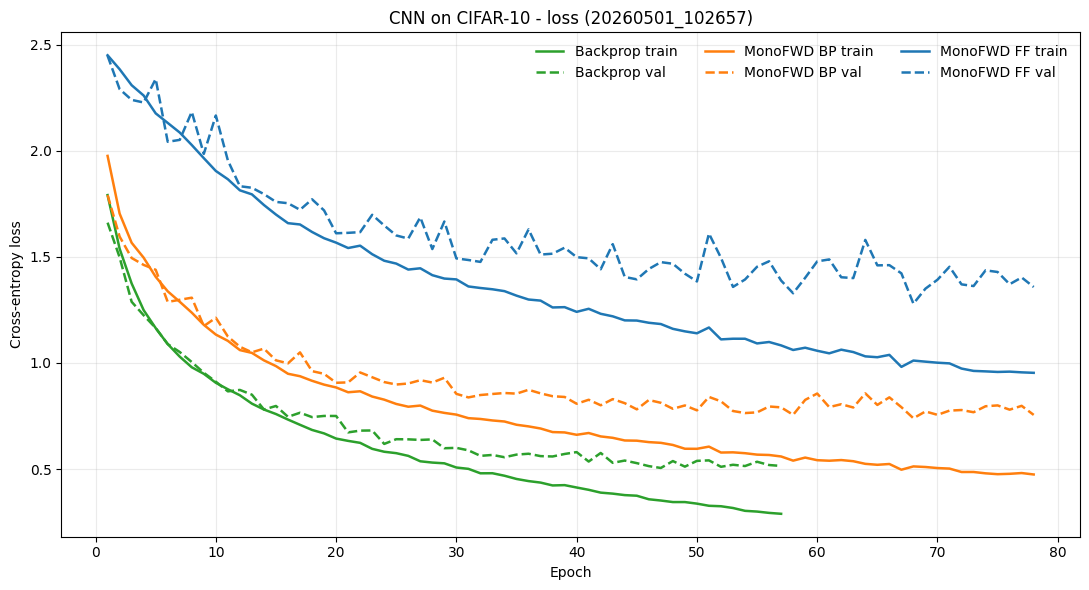

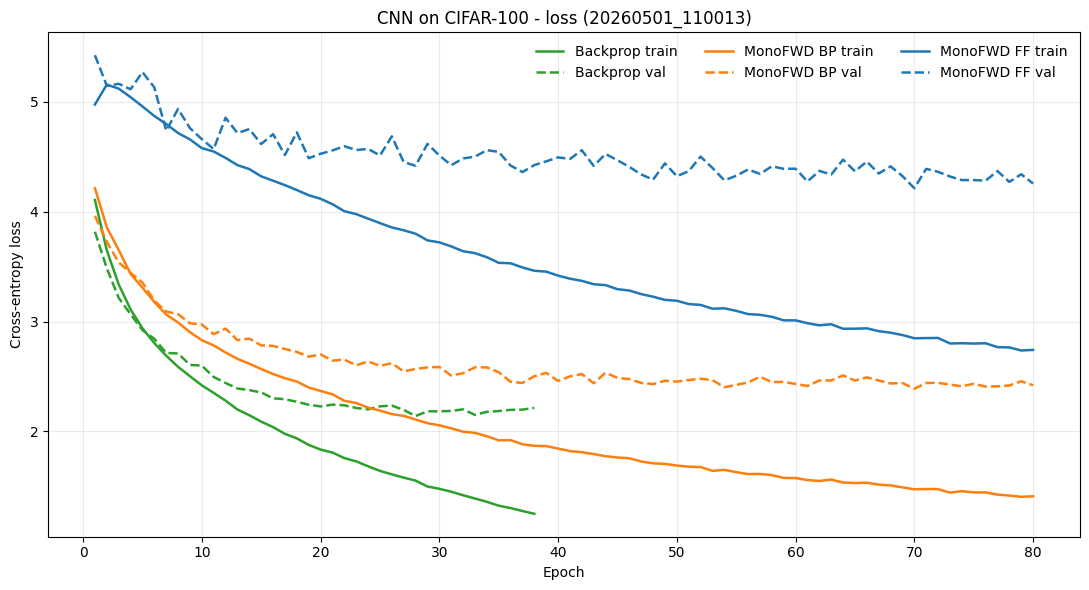

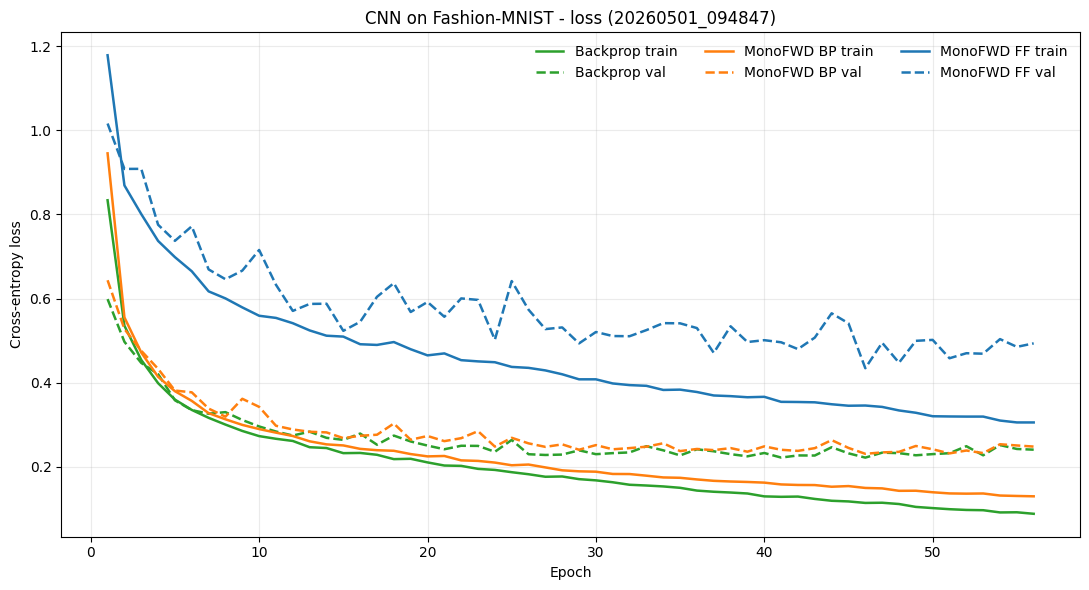

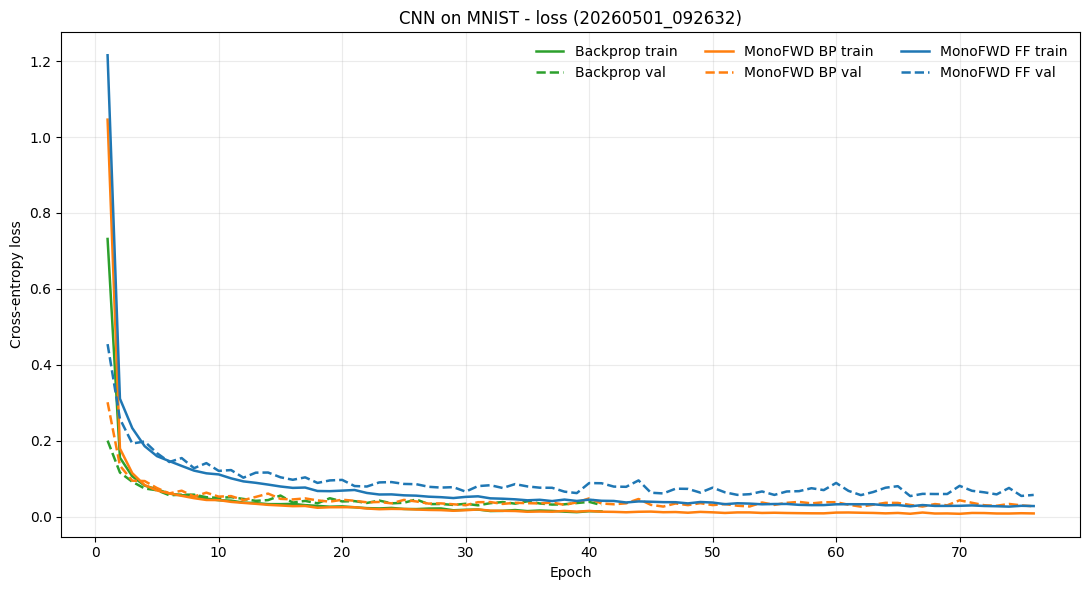

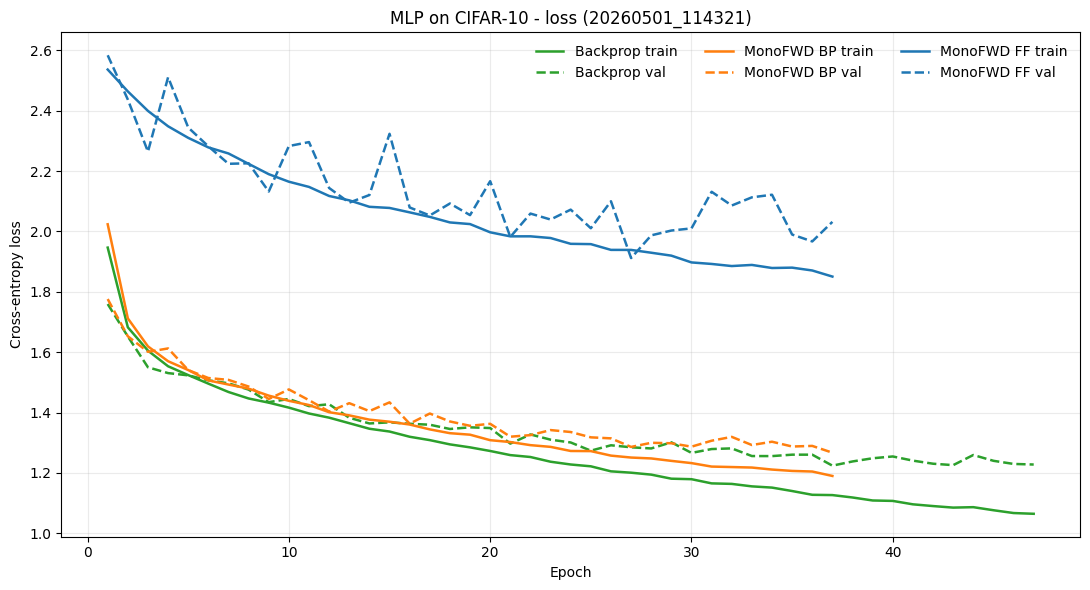

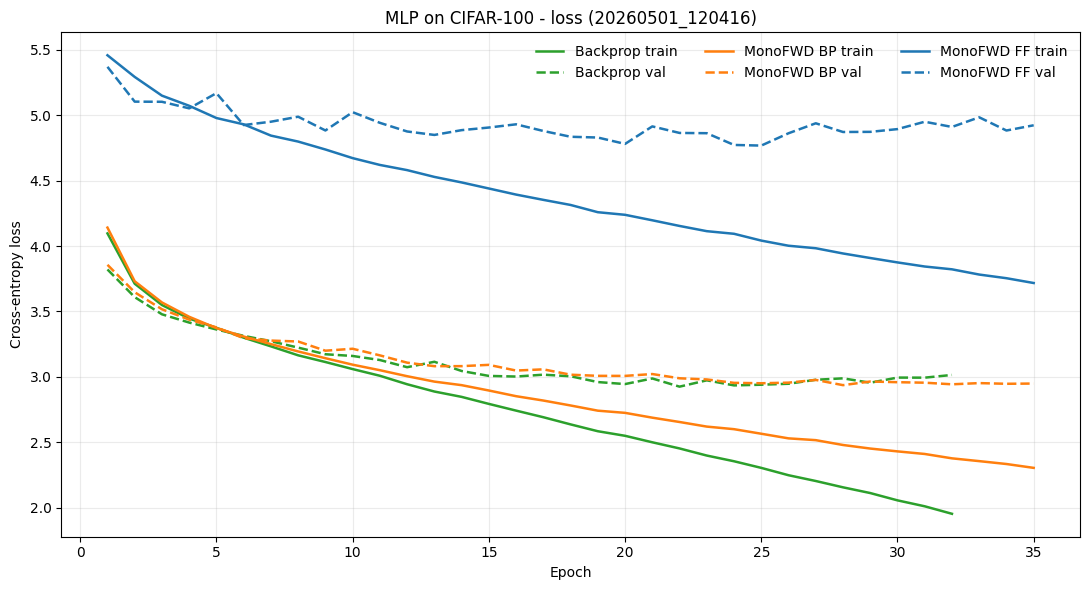

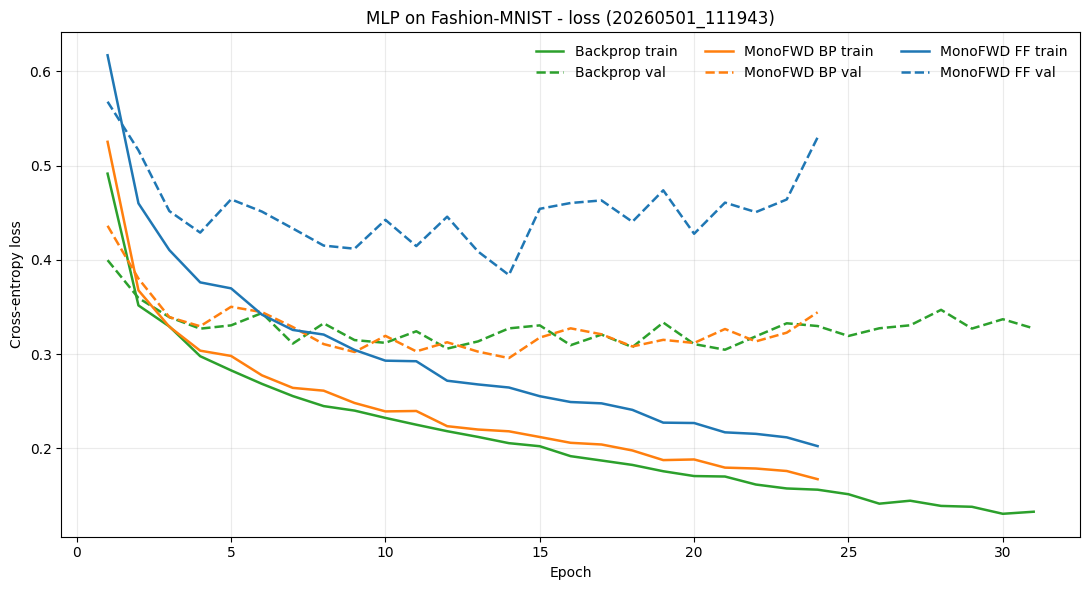

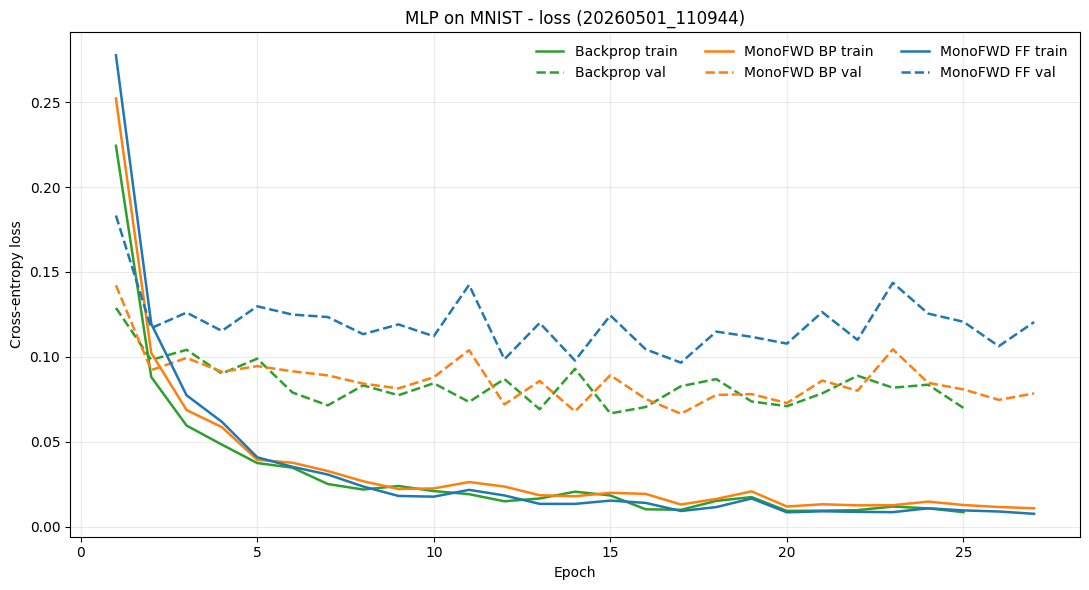

,model_label,dataset_label,run_id,method_label,test_loss
1654,CNN,CIFAR-10,20260501_102657,Backprop,0.534556
1424,CNN,CIFAR-10,20260501_102657,MonoFWD BP,0.785882
1110,CNN,CIFAR-10,20260501_102657,MonoFWD FF,1.345516
796,CNN,CIFAR-100,20260501_110013,Backprop,2.113503
642,CNN,CIFAR-100,20260501_110013,MonoFWD BP,2.367461
320,CNN,CIFAR-100,20260501_110013,MonoFWD FF,4.124538
2332,CNN,Fashion-MNIST,20260501_094847,Backprop,0.246166
2106,CNN,Fashion-MNIST,20260501_094847,MonoFWD BP,0.253443
1880,CNN,Fashion-MNIST,20260501_094847,MonoFWD FF,0.481097
3110,CNN,MNIST,20260501_092632,Backprop,0.026224


In [3]:
method_colors = {
    "MonoFWD FF": "tab:blue",
    "MonoFWD BP": "tab:orange",
    "Backprop": "tab:green",
}
split_styles = {"train": "-", "val": "--", "test": "None"}
split_markers = {"train": None, "val": None, "test": "o"}

loss_groups = losses[losses["split"] != "test"].groupby(
    ["model_label", "dataset_label", "run_id"],
    sort=True,
)

for (model_label, dataset_label, run_id), experiment_losses in loss_groups:
    fig, ax = plt.subplots(figsize=(11, 6))

    for (method_label, split), group in experiment_losses.groupby(
        ["method_label", "split"],
        sort=True,
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            marker=split_markers[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(f"{model_label} on {dataset_label} - loss ({run_id})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

test_loss_summary = (
    losses[losses["split"] == "test"]
    .sort_values(["model_label", "dataset_label", "run_id", "method_label"])
    [["model_label", "dataset_label", "run_id", "method_label", "value"]]
    .rename(columns={"value": "test_loss"})
)

display(test_loss_summary)


## Accuracy curves


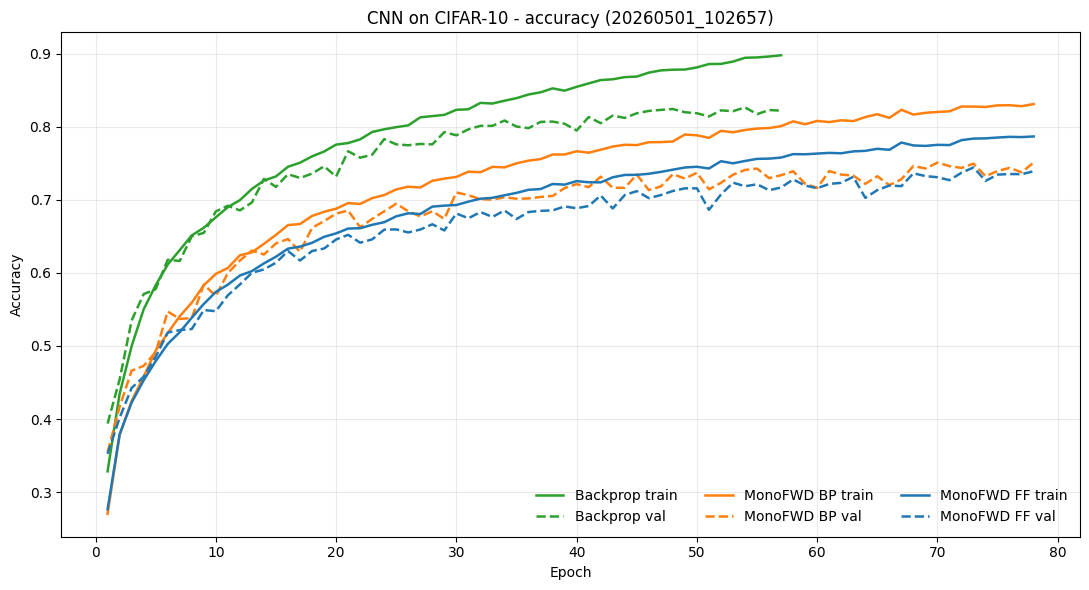

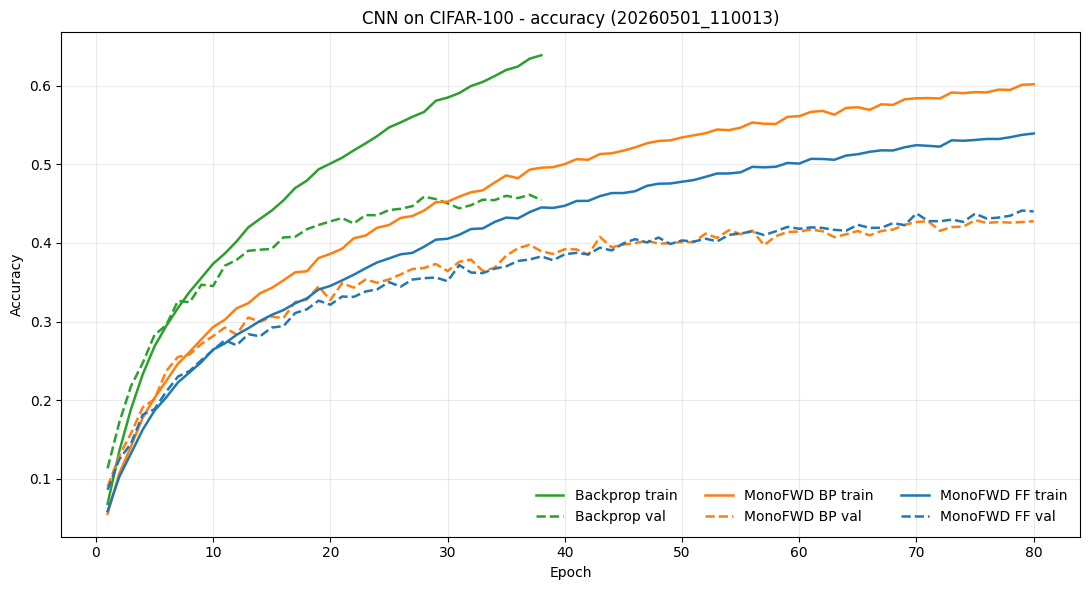

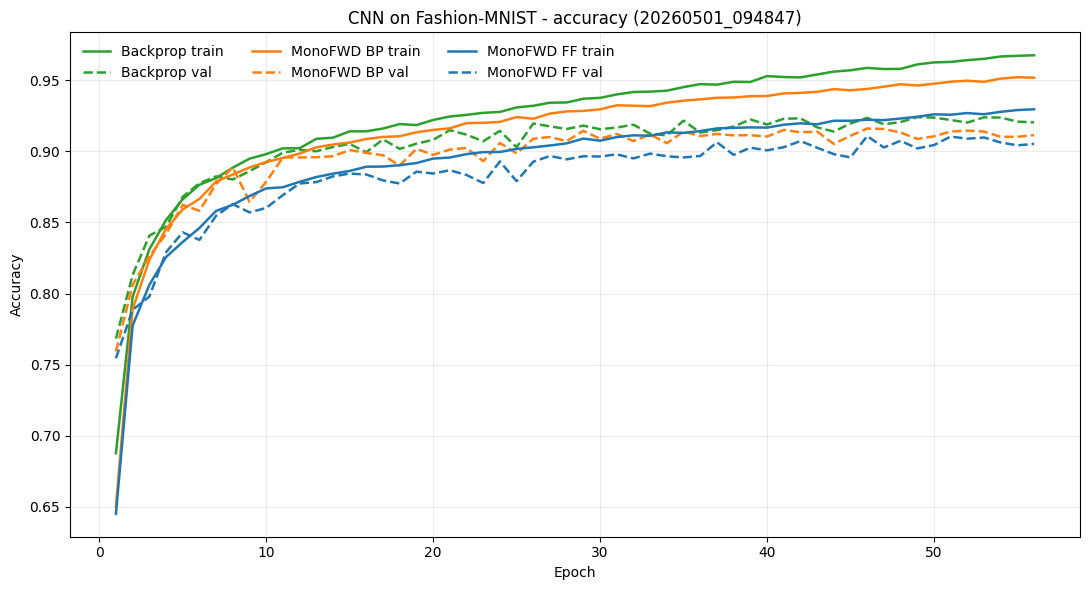

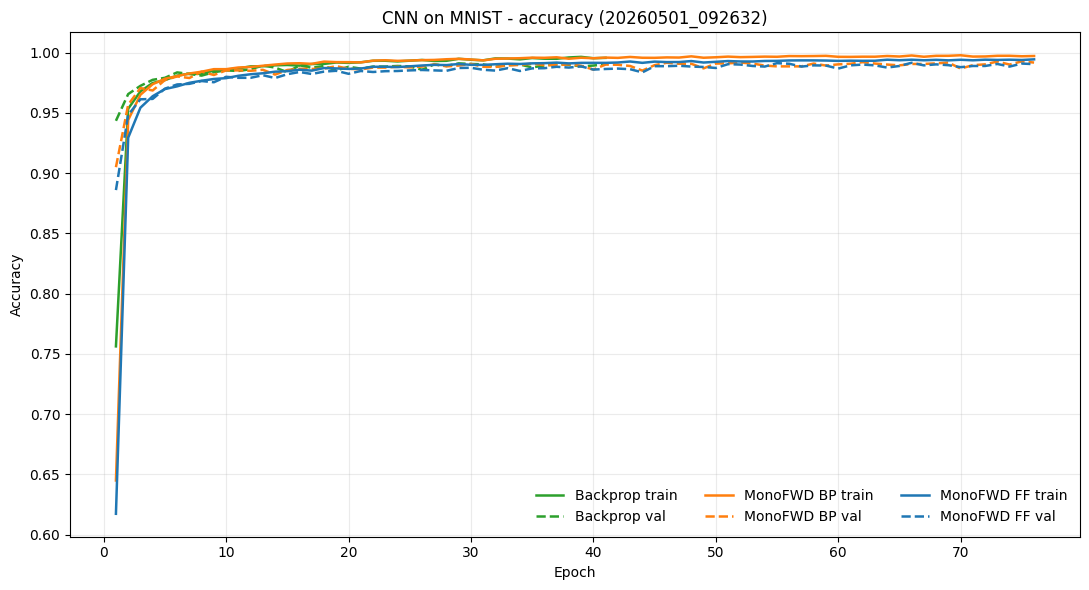

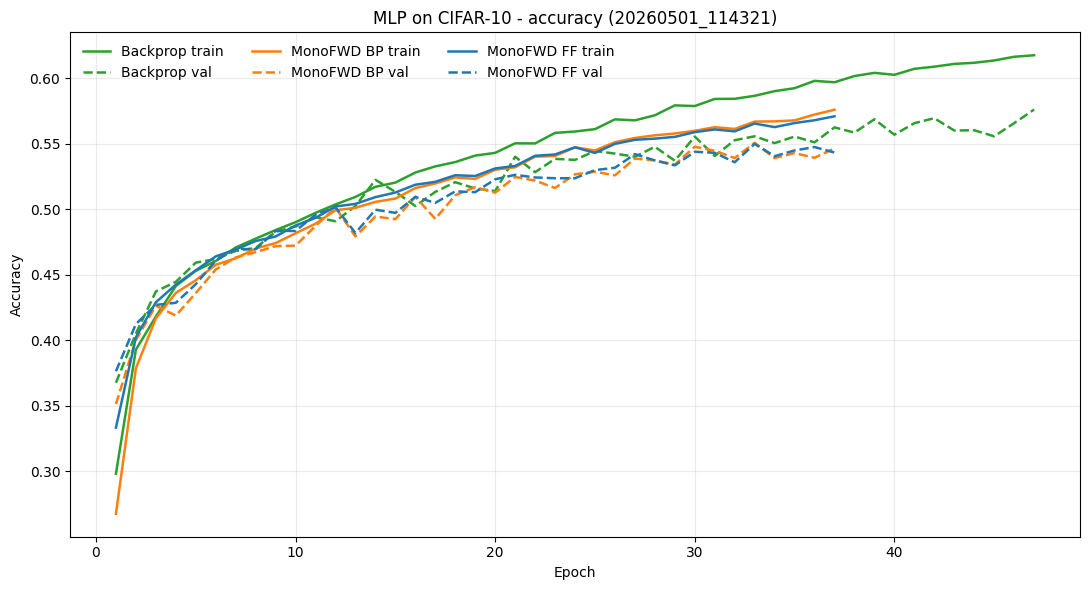

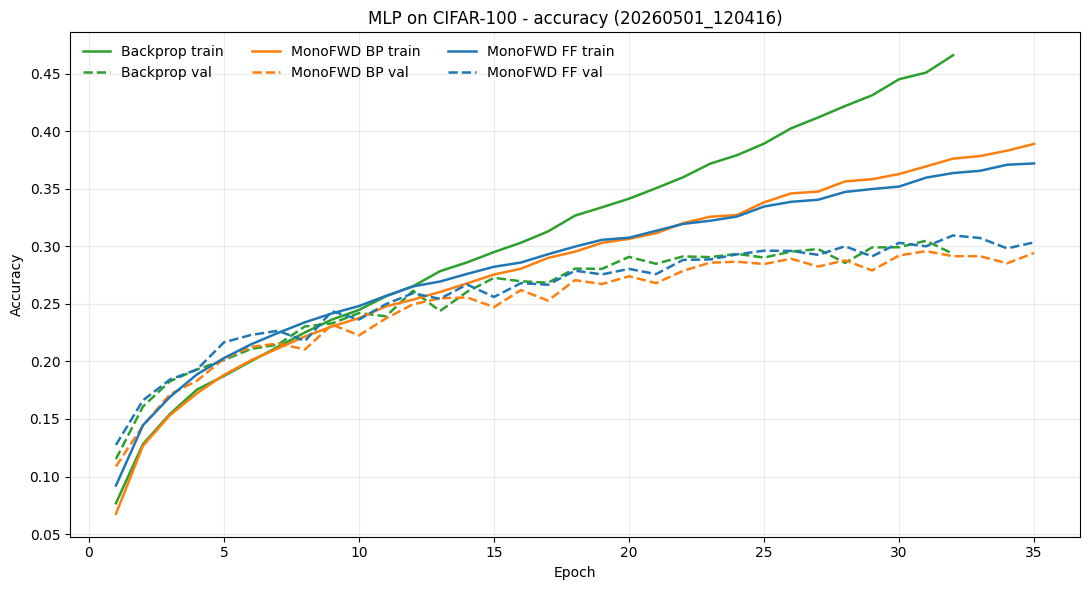

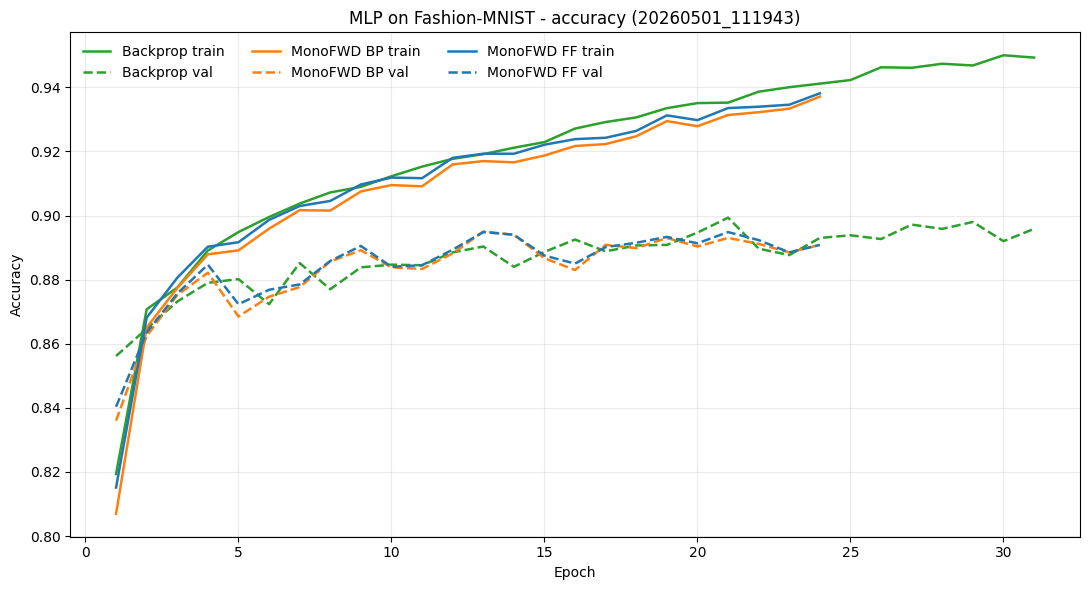

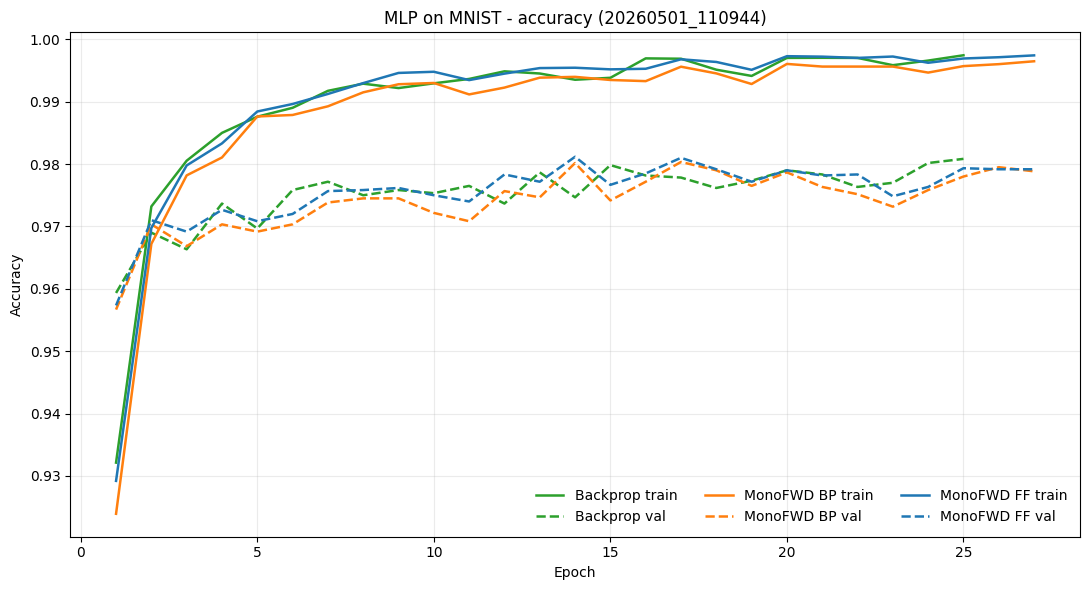

,model_label,dataset_label,run_id,method_label,test_accuracy
1655,CNN,CIFAR-10,20260501_102657,Backprop,0.8175
1425,CNN,CIFAR-10,20260501_102657,MonoFWD BP,0.7369
1111,CNN,CIFAR-10,20260501_102657,MonoFWD FF,0.7283
797,CNN,CIFAR-100,20260501_110013,Backprop,0.4598
643,CNN,CIFAR-100,20260501_110013,MonoFWD BP,0.4255
321,CNN,CIFAR-100,20260501_110013,MonoFWD FF,0.4406
2333,CNN,Fashion-MNIST,20260501_094847,Backprop,0.9179
2107,CNN,Fashion-MNIST,20260501_094847,MonoFWD BP,0.9139
1881,CNN,Fashion-MNIST,20260501_094847,MonoFWD FF,0.9071
3111,CNN,MNIST,20260501_092632,Backprop,0.9917


In [4]:
accuracy_groups = accuracies[accuracies["split"] != "test"].groupby(
    ["model_label", "dataset_label", "run_id"],
    sort=True,
)

for (model_label, dataset_label, run_id), experiment_accuracies in accuracy_groups:
    fig, ax = plt.subplots(figsize=(11, 6))

    for (method_label, split), group in experiment_accuracies.groupby(
        ["method_label", "split"],
        sort=True,
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            marker=split_markers[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(f"{model_label} on {dataset_label} - accuracy ({run_id})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

test_accuracy_summary = (
    accuracies[accuracies["split"] == "test"]
    .sort_values(["model_label", "dataset_label", "run_id", "method_label"])
    [["model_label", "dataset_label", "run_id", "method_label", "value"]]
    .rename(columns={"value": "test_accuracy"})
)

display(test_accuracy_summary)
